# Data Cleaning
### Tolong baca perintah dan tagar komen dengan saksama :)

# A. Handling Duplicate

## Tugas :
Lakukan investigasi pada file `Telco-Customer-Churn.csv` apakah file tersebut memiliki data yang duplicate. Jika iya, handling duplicate tersebut!

In [ ]:
import pandas as pd
df_telco = pd.read_csv('Telco-Customer-Churn.csv')
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# dikode ini kita akan mengecek apakah ada data yang duplicate

cek_duplicate = df_telco.duplicated().sum()

print(cek_duplicate)

0


In [ ]:
# kita akan menampilkan baris-baris yang duplicate

baris_duplicate = df_telco[df_telco.duplicated(keep=False)]
baris_duplicate

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


# Melakukan Handling Duplicate
*   Dataset Telco-Customer-Churn.csv sudah bersih dari duplikasi data.
*   Tidak diperlukan langkah handling duplicate seperti drop_duplicates().
*   Dengan demikian, kita bisa lanjut ke tahap pembersihan data berikutnya (misalnya outlier handling atau missing value handling) tanpa khawatir ada data ganda yang bisa memengaruhi analisis.





# B. Outlier Handling

## Tugas

1. Cek distribusi pada kolom : `['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup']` di `california_dataset.csv` dan cek apakah terdapat outlier pada kolom-kolom tersebut
2. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
3. Cek distribusinya kembali

In [ ]:
df_california = pd.read_csv('california_dataset.csv')

In [ ]:
df_california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   house_price  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df_california.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


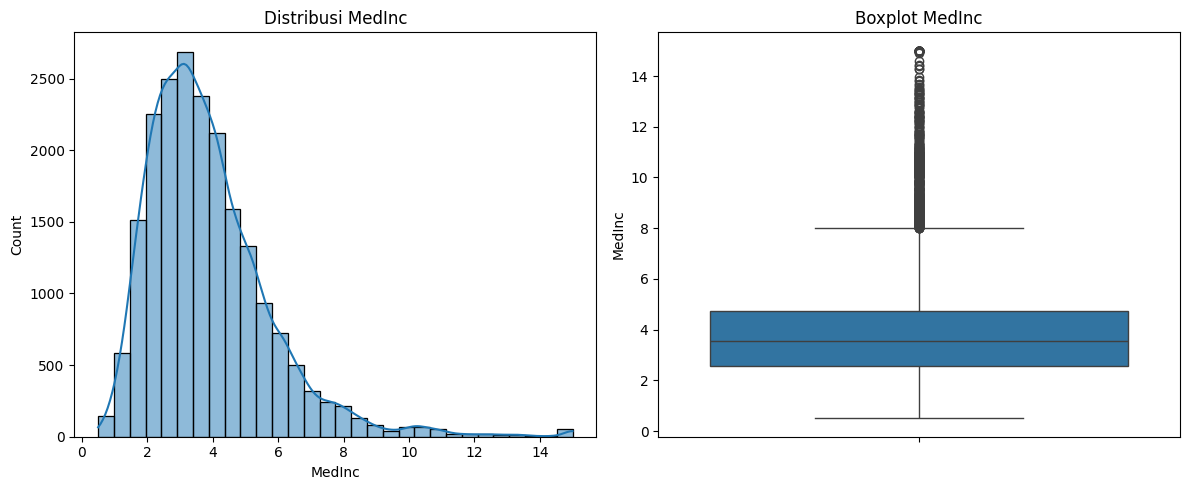

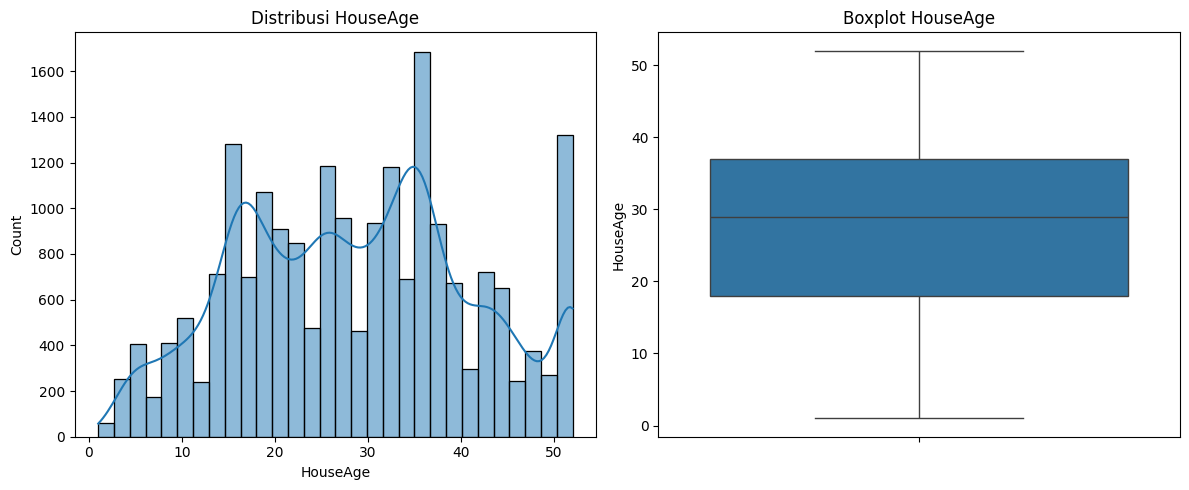

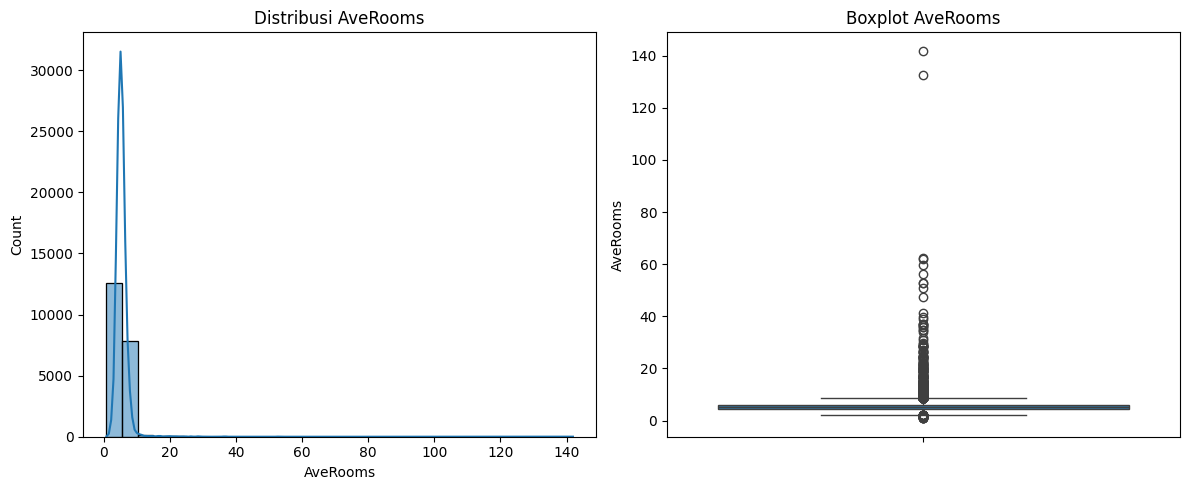

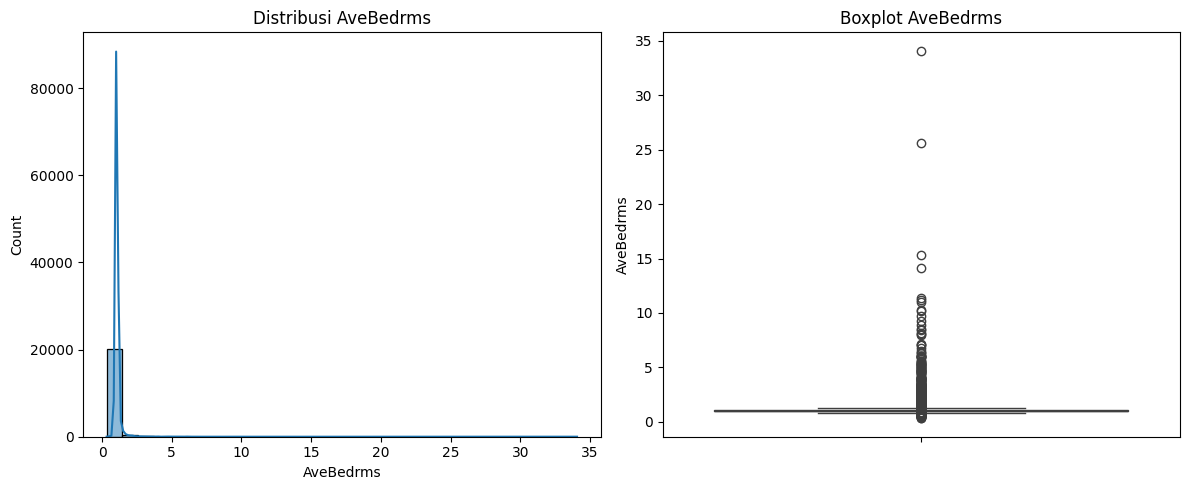

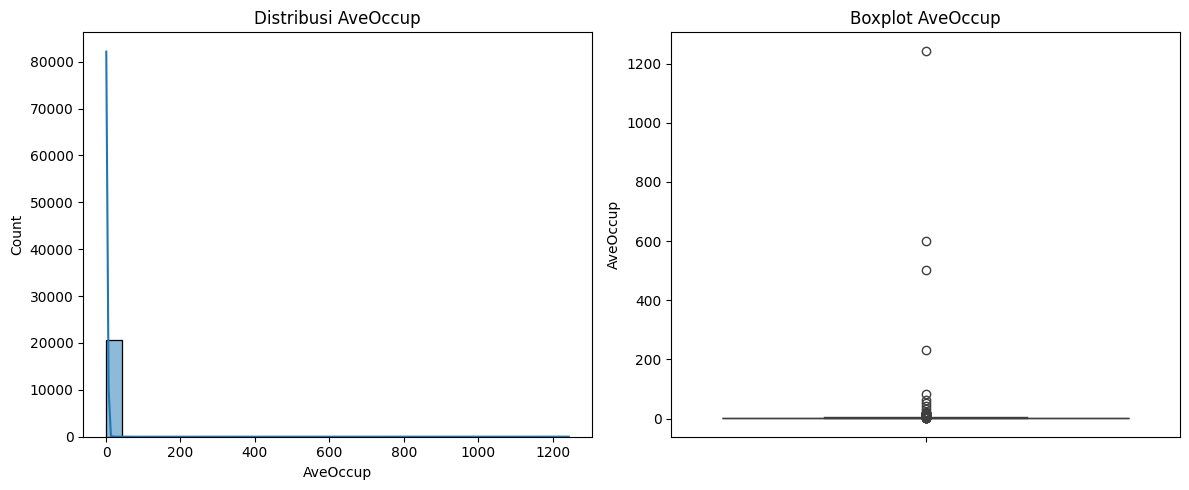

In [ ]:
'''
Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom :
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
'''

import matplotlib.pyplot as plt
import seaborn as sns

# Kolom yang Ingin Dicek Outlier
kolom_outlier = ['MedInc','HouseAge','AveRooms','AveBedrms','AveOccup']

# Looping Visualisasi
for col in kolom_outlier:
    plt.figure(figsize=(12,5))

    # Histogram (Cek Distribusi)
    plt.subplot(1,2,1)
    sns.histplot(df_california[col], bins=30, kde=True)
    plt.title(f'Distribusi {col}')

    # Boxplot (Cek Outlier)
    plt.subplot(1,2,2)
    sns.boxplot(y=df_california[col])
    plt.title(f'Boxplot {col}')

    plt.tight_layout()
    plt.show()



**Interpretasi per Kolom**

1. MedInc (Median Income / Pendapatan Median)
*   Histogram → Distribusi cenderung skewed ke kanan (right-skewed). Artinya, mayoritas pendapatan berada di kisaran rendah–menengah, sedangkan sebagian kecil memiliki pendapatan sangat tinggi.
*   Boxplot → Terlihat cukup banyak titik outlier di bagian atas, menunjukkan adanya rumah tangga dengan pendapatan jauh lebih tinggi dari mayoritas.
*   Insight: Distribusi pendapatan tidak merata, mayoritas pendapatan rendah, sedikit sekali ada minoritas dengan pendapatan sangat tinggi tapi signifikan sebagai outlier.

2. HouseAge (Usia Rumah)
*   Histogram → Distribusi agak unik: ada puncak tajam di usia 52. Banyak rumah “stuck” di angka ini (kemungkinan data capping / batas atas pada dataset asli).
*   Boxplot → Hampir tidak ada outlier yang ekstrem, tapi nilai cenderung berkumpul di usia menengah (20–30 tahun) dan di 52.
*   Insight: Data usia rumah banyak menumpuk di satu nilai (52), menandakan mungkin ada pencatatan khusus (misalnya rumah tua semua dianggap “52 tahun”).

3. AveRooms (Rata-rata jumlah kamar per rumah tangga)
*   Histogram → Distribusi right-skewed: sebagian besar rumah punya jumlah kamar rata-rata kecil (sekitar 4–7 kamar), tapi ada sebagian yang jumlah kamarnya sangat besar.
*   Boxplot → Ada banyak outlier di bagian atas → rumah tangga dengan jumlah kamar rata-rata sangat besar, jauh di atas mayoritas.
*   Insight: Mayoritas rumah berukuran kecil–menengah, tapi ada outlier dengan kamar jauh lebih banyak (kemungkinan rumah mewah atau data entry aneh).

4. AveBedrms (Rata-rata jumlah kamar tidur per rumah tangga)
*   Histogram → Distribusi condong ke kiri (kebanyakan < 2 kamar tidur per rumah tangga).
*   Boxplot → Ada beberapa outlier di bagian atas (jumlah kamar tidur rata-rata > 5 per rumah tangga).
*   Insight: Sebagian besar rumah punya kamar tidur sedikit, tapi ada rumah dengan kamar tidur yang jauh lebih banyak, terlihat sebagai outlier.

5. AveOccup (Rata-rata jumlah penghuni per rumah tangga)
*   Histogram → Distribusi sangat skewed ke kanan. Sebagian besar rumah dihuni < 4 orang, tapi ada data dengan penghuni > 30 bahkan 1243 orang.
*   Boxplot → Outlier ekstrem di bagian atas → rumah tangga dengan penghuni tidak wajar banyaknya.
*   Insight: Sebagian besar rumah tangga kecil, tapi ada data outlier dengan penghuni terlalu banyak (bisa jadi kesalahan input data atau kondisi khusus seperti asrama).





















# Melakukan Handling Outlier Pada Kolom AveRooms



In [ ]:
# Menghitung Q1, Q3, dan IQR

Q1 = df_california["AveRooms"].quantile(0.25)
Q3 = df_california["AveRooms"].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Q1: 4.440716235896959
Q3: 6.052380952380952
IQR: 1.6116647164839932


In [ ]:
# Menentukan Batas Bawah & Atas
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Lower Bound: 2.023219161170969
Upper Bound: 8.469878027106942


In [ ]:
'''
  filter kolom "AveRooms" untuk outlier yang memiliki nilai
  diatas UPPER BOUNDARY dan dibawah LOWER BOUNDARY
'''

df_california = df_california[(df_california["AveRooms"] <= upper_bound) & (df_california["AveRooms"] >= lower_bound)]

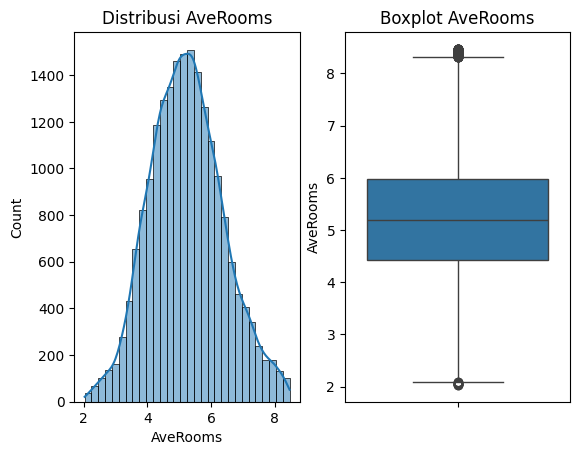

In [ ]:
# Cek Histogram Setelah Handling Outlier
plt.subplot(1,2,1)
sns.histplot(df_california['AveRooms'], bins=30, kde=True)
plt.title(f"Distribusi AveRooms")

# Cek Boxplot Setelah Handling Outlier
plt.subplot(1,2,2)
sns.boxplot(y=df_california['AveRooms'])
plt.title(f"Boxplot AveRooms")
plt.show()


**Interpretasi**

1. Outlier berkurang signifikan → dibandingkan sebelumnya (dimana hampir semua nilai dianggap outlier), sekarang outlier tinggal sedikit. Itu berarti metode IQR sudah berhasil membersihkan data ekstrem yang terlalu jauh.
2. Masih ada outlier sisa → hal ini wajar, karena metode IQR hanya membuang nilai yang berada jauh sekali di luar range normal. Jika distribusi data memang agak lebar atau skewed, masih ada kemungkinan tersisa beberapa outlier.
3. Dampak pada distribusi → histogram sekarang terlihat jauh lebih wajar dengan puncak jelas di sekitar 4–6 kamar. Outlier sisa ini tidak lagi mendistorsi distribusi utama.
4. Kesimpulan
*   Handling IQR sudah berhasil membuat data lebih representatif.
*   Kehadiran outlier kecil yang tersisa tidak selalu harus dihapus, karena bisa saja memang mencerminkan data valid (misalnya rumah yang benar-benar punya lebih banyak kamar).
*   Langkah selanjutnya perlu didiskusikan dengan tim untuk menentukan apakah outlier kecil ini dibiarkan (agar data tetap merepresentasikan kondisi riil) atau dihapus (jika tujuan analisis mengutamakan model yang lebih robust).





# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

## Tugas :
1. Investigasi hanya pada kolom `Headquarters` di `company.csv`, Cek jenis missing valuenya apakah ada atau tidak?
2. Lakukan handling missing value

In [ ]:
df_company = pd.read_csv('company.csv')

In [ ]:
#Tulis jawaban missing value handling kolom Headquarters disini
# Cek missing value dalam dataset

df_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Revenue       672 non-null    object 
 1   Size          672 non-null    object 
 2   Rating        622 non-null    float64
 3   Headquarters  672 non-null    object 
dtypes: float64(1), object(3)
memory usage: 21.1+ KB


In [ ]:
df_company

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,NaN,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"
...,...,...,...,...
667,Unknown / Non-Applicable,1001 to 5000 employees,3.6,"Fort Lee, NJ"
668,-1,-1,-1.0,-1
669,-1,-1,-1.0,-1
670,$1 to $5 million (USD),1 to 50 employees,5.0,"Santa Clara, CA"


In [ ]:
# sort value to investigate the data

df_company.sort_values(by='Headquarters', ascending = False)

,Revenue,Size,Rating,Headquarters
60,$10+ billion (USD),10000+ employees,3.8,"Zurich, Switzerland"
86,Unknown / Non-Applicable,501 to 1000 employees,2.6,"Yakima, WA"
225,$5 to $10 million (USD),51 to 200 employees,4.5,"Woodbridge, NJ"
355,$1 to $5 million (USD),1 to 50 employees,5.0,"Woodbine, MD"
507,$1 to $5 million (USD),1 to 50 employees,5.0,"Woodbine, MD"
...,...,...,...,...
360,-1,-1,NaN,-1
389,-1,-1,-1.0,-1
388,-1,-1,-1.0,-1
650,-1,-1,-1.0,-1


In [ ]:
# Mengecek jumlah missing value di kolom Headquarters
df_company['Headquarters'].isna().sum()

np.int64(0)

In [ ]:
# Mengecek bentuk nilai unik untuk memastikan ada yang kosong/aneh

df_company["Headquarters"].value_counts(dropna=False)


,count
Headquarters,
"New York, NY",33
"San Francisco, CA",31
-1,31
"Chicago, IL",23
"Boston, MA",19
...,...
"Oakville, Canada",1
"San Bruno, CA",1
"West Chester, PA",1


# Melakukan Missing Value Handling pada Kolom Headquarters

Berdasarkan hasil eksplorasi, kolom Headquarters tidak memiliki missing value eksplisit (NaN), namun ditemukan adanya nilai aneh yaitu "-1". Nilai tersebut bukan merupakan nama kota yang valid, sehingga dapat dikategorikan sebagai missing value terselubung atau invalid entry.

Sebelum melakukan penanganan lebih lanjut, sebaiknya dilakukan konfirmasi ke tim terkait (misalnya tim data engineer atau tim bisnis) untuk memastikan apakah nilai "-1" memang dimaksudkan sebagai kategori tertentu, atau seharusnya dianggap sebagai data hilang (missing value).

Apabila sudah dipastikan bahwa "-1" bukan kategori yang valid, maka nilai tersebut akan diperlakukan sebagai missing value dengan cara mengubahnya menjadi NaN. Setelah itu, persentase missing value terhadap total data akan dihitung untuk menentukan strategi handling lebih lanjut.

In [ ]:
import numpy as np

# Ubah nilai -1 jadi NaN
df_company["Headquarters"] = df_company["Headquarters"].replace("-1", np.nan)

# Hitung jumlah & persentase missing value
missing_count = df_company["Headquarters"].isna().sum()
total_count = len(df_company)
missing_percentage = (missing_count / total_count) * 100

print(f"Missing value count: {missing_count}")
print(f"Missing value percentage: {missing_percentage:.2f}%")


Missing value count: 31
Missing value percentage: 4.61%


**Dari Hasil Perhitungan :**

*   Persentase missing value (nilai "-1") di kolom Headquarters = 4.61%.
*   Karena < 20%, data tidak perlu di-drop → sebaiknya diimputasi.
*   Karena tipe datanya kategorikal (lokasi kantor pusat), cara paling umum adalah melakukan Imputasi dengan modus (nilai yang paling sering muncul), misalnya New York, NY kalau memang jadi lokasi terbanyak.





In [ ]:
# Cari modus
mode_value = df_company["Headquarters"].mode()[0]

# Imputasi missing value dengan modus
df_company["Headquarters"] = df_company["Headquarters"].fillna(mode_value)

print("Nilai modus:", mode_value)
print("Jumlah missing value setelah imputasi:", df_company["Headquarters"].isna().sum())


Nilai modus: New York, NY
Jumlah missing value setelah imputasi: 0


In [ ]:
# Cek Ulang Disttribusi Data
print(df_company["Headquarters"].value_counts().head(10))


Headquarters
New York, NY                 64
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Name: count, dtype: int64


**Interpretasi**

*   Sebelum dilakukan imputasi, terdapat 31 baris data dengan nilai -1 pada kolom Headquarters, yang dianggap sebagai missing value (sekitar 4.61% dari total data).
*   Karena persentase missing value relatif kecil < 20%, maka dipilih metode imputasi menggunakan modus (nilai yang paling sering muncul).
*   Nilai modus pada kolom ini adalah "New York, NY", sehingga semua entri yang bernilai -1 diisi dengan "New York, NY".

**Dampak dari Imputasi**

*   Setelah imputasi, jumlah entri "New York, NY" meningkat dari 33 menjadi 64.
*   Hal ini wajar karena seluruh missing value digantikan dengan nilai modus tersebut.
*   Distribusi lokasi lain (misalnya San Francisco, CA, Chicago, IL, dll.) tidak berubah, hanya frekuensi "New York, NY" yang bertambah.

**Kesimpulan**

*   Missing value berhasil ditangani, jumlah missing value sekarang menjadi 0.
*   Perlu dicatat bahwa imputasi ini bisa membuat data sedikit bias ke arah "New York, NY", sehingga interpretasi selanjutnya (misalnya analisis sebaran kantor pusat) harus mempertimbangkan bahwa sebagian nilai diisi berdasarkan modus, bukan data asli.
*   Untuk validasi lebih lanjut, sebaiknya dilakukan konfirmasi ke tim/data owner apakah benar -1 adalah missing value atau justru kategori khusus.











# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling.

## Tugas :

Lakukan investigasi pada kolom `gender`, `PaymentMethod`, `Churn` pada file `Telco-Customer-Churn.csv`. Perhatikan jenis data categorical-nya dan lakukan encoding dengan teknik yang paling tepat pada kolom-kolom tersebut

In [ ]:
df_churn = pd.read_csv('Telco-Customer-Churn.csv')

In [ ]:
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ambil semua kolom bertipe object

obj_column = df_churn.select_dtypes(include='object').columns
print(obj_column)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [ ]:
# Pilih hanya kolom yang mau dicek
cek_kolom = ['gender', 'PaymentMethod', 'Churn']

for column in cek_kolom:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()


============= gender =================


,count
gender,
Male,3555
Female,3488



============= PaymentMethod =================


,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522



============= Churn =================


,count
Churn,
No,5174
Yes,1869


# Label Encoding

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Label Encoding untuk gender dan churn
le = LabelEncoder()
df_churn['gender'] = le.fit_transform(df_churn['gender'])
df_churn['Churn'] = le.fit_transform(df_churn['Churn'])
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**Interpretasi Kolom Gender**

1. Kolom gender awalnya berisi "Male" dan "Female".
2. Setelah Label Encoding, kategori diubah menjadi numerik:
*   "Female" → 0
*   "Male" → 1
3. Kenapa memakai teknik Label Encoding?
*   Karena gender hanya punya 2 kategori (biner).
*   Jika dipakai One-Hot Encoding, hasilnya akan menghasilkan 2 kolom dummy (gender_Female dan gender_Male), padahal cukup 1 kolom saja.
*   Dengan Label Encoding, representasi data lebih ringkas, sederhana, dan efisien.
4. Catatan: Label Encoder otomatis memberi angka berdasarkan alfabetis (Female < Male) sehingga kita tidak bisa memilih sendiri siapa yang jadi 0 atau 1.

**Interpretasi Kolom Churn**
1. Kolom Churn awalnya "Yes" (berhenti berlangganan) dan "No" (tetap berlangganan).
2. Setelah Label Encoding, kategori diubah menjadi numerik:
*   "No" → 0
*   "Yes" → 1
3. Kenapa memakai teknik Label Encoding?
*   Sama seperti gender, Churn hanya memiliki 2 kategori (biner).
*   Label Encoding membuatnya langsung menjadi variabel target biner yang cocok untuk pemodelan klasifikasi.
*   Jika dipakai One-Hot Encoding, malah boros kolom karena hasilnya hanya 2 dummy yang berulang.
4. Catatan: Angka 0 dan 1 diberikan otomatis oleh Label Encoder berdasarkan urutan alfabet (No < Yes).











# One Hot Encoding

In [ ]:
# One-Hot Encoding untuk PaymentMethod
df_churn = pd.get_dummies(df_churn, columns=['PaymentMethod'])
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,29.85,29.85,0,False,False,True,False
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,56.95,1889.5,0,False,False,False,True
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,53.85,108.15,1,False,False,False,True
3,7795-CFOCW,1,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,42.30,1840.75,0,True,False,False,False
4,9237-HQITU,0,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,70.70,151.65,1,False,False,True,False


In [ ]:
# Ubah OHE gender dari True/False menjadi 0/1
for col in df_churn.columns:
    if 'PaymentMethod' in col:
        df_churn[col] = df_churn[col].astype(int)
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,29.85,29.85,0,0,0,1,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,56.95,1889.5,0,0,0,0,1
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,53.85,108.15,1,0,0,0,1
3,7795-CFOCW,1,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,42.30,1840.75,0,1,0,0,0
4,9237-HQITU,0,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,70.70,151.65,1,0,0,1,0


**Interpretasi PaymentMethod**
1. Transformasi Data
*   Kolom PaymentMethod awalnya berupa data kategorikal dengan beberapa metode pembayaran (misalnya: Electronic check, Mailed check, Bank transfer, Credit card).
*   Nilai dalam kolom dummy berupa 0 atau 1 (0 = pelanggan tidak menggunakan metode pembayaran tersebut, 1 = pelanggan menggunakan metode tersebut).
*   Setelah dilakukan One-Hot Encoding, setiap metode pembayaran diubah menjadi kolom dummy baru.

Contoh:
*   PaymentMethod_Electronic check
*   PaymentMethod_Mailed check
*   PaymentMethod_Bank transfer (automatic)
*   PaymentMethod_Credit card (automatic)

2. Kelebihan Pendekatan One-Hot Encoding
*   Model machine learning bisa memproses variabel kategorikal dengan benar.
*   Tidak ada asumsi urutan (ranking) antar kategori, karena setiap metode berdiri sendiri.
*   Menghindari kesalahan interpretasi yang bisa muncul kalau kita memakai Label Encoding (misalnya menganggap Electronic check = 0 lebih kecil/rendah daripada Credit card = 3).

3. Dampak pada Dataset
*   Jumlah kolom bertambah sesuai jumlah kategori di PaymentMethod.
*   Dataset jadi lebih informatif karena setiap metode pembayaran diwakili secara eksplisit.
*   Namun, dataset juga jadi lebih “lebar” (dimensionalitas meningkat), sehingga perlu diperhatikan untuk dataset yang sangat besar.

4. Kesimpulan
*   PaymentMethod berhasil diubah menjadi variabel numerik dengan representasi 0/1.
*   Teknik One-Hot Encoding dipilih karena paling tepat untuk kolom kategorikal dengan banyak kategori (multiclass).
*   Sekarang data siap dipakai untuk analisis lebih lanjut atau modeling machine learning.



















## Thank you :)